<a href="https://colab.research.google.com/github/Emilio-Tecu/Simulation-of-RF-Photon-Transport-through-a-Turbulent-Interplanetary-Medium/blob/main/Clasificador_de_se%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías pertinentes para la creación y entrenamiento de la red.
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Librerías de manipulación y gráfica de datos.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import cauchy

In [ ]:
# Importamos drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Leemos los datos generados por la simulación.
ruta_archivo = '/content/drive/MyDrive/Simulación de sistemas físicos/A_50000_sistemas.csv'
df = pd.read_csv(ruta_archivo)
df.head()

,Delta_nu_sb_Hz,Es_Enana_M_1_Sol_0
0,7.159574,1
1,9.008969,1
2,1.593825,1
3,0.925611,0
4,3.737625,1


## Manipulación de datos.

In [ ]:
# Guardamos los ensanchamientos.
anchos_simulados = df['Delta_nu_sb_Hz'].values
anchos_simulados

array([  7.159574,   9.008969,   1.593825, ...,  59.27391 , 162.7179  ,
       255.1324  ])

In [ ]:
# Parámetros del radiotelescopio simulado.
# Número de puntos (bins) en el espectro.
num_canales = 200
rango_frecuencias = (-15, 15) # En Hz.
eje_frecuencias = np.linspace(rango_frecuencias[0], rango_frecuencias[1], num_canales)

In [ ]:
# Generamos el dataset en base a datos simulados.
def generar_dataset_separado(anchos, snr_min=0.5, snr_max=7.0):
    """
    Generamos las dos clases: Clase 1 (Señales) y Clase 0 (Ruido) en arreglos separados.
    Introducimos un SNR dinámico para hacer la red neuronal más robusta.
    """
    X_senales = []
    y_senales = []

    X_ruidos = []
    y_ruidos = []

    print(f"Generando dataset para {len(anchos)} sistemas con SNR variable entre {snr_min} y {snr_max}...")

    for ancho in anchos:
        # Parámetro gamma de Cauchy.
        gamma = ancho / 2.0
        # Generamos la señal perfecta centrada en 0.
        senal_ideal = cauchy.pdf(eje_frecuencias, loc=0, scale=gamma)
        # Normalizamos.
        senal_ideal = senal_ideal / np.max(senal_ideal)
        # Elegimos un SNR aleatorio.
        snr_actual = np.random.uniform(snr_min, snr_max)
        # Calculamos la amplitud del ruido basada en el SNR deseado.
        desviacion_ruido = 1.0 / snr_actual
        # Generamos ruido térmico.
        ruido_termico = np.random.normal(loc=0.0, scale=desviacion_ruido, size=num_canales)
        # Sumamos para obtener la señal.
        espectro_con_senal = senal_ideal + ruido_termico
        # Agregamos a la clase.
        X_senales.append(espectro_con_senal)
        y_senales.append(1)

        # Generamos full ruido.
        ruido_puro = np.random.normal(loc=0.0, scale=desviacion_ruido, size=num_canales)

        X_ruidos.append(ruido_puro)
        y_ruidos.append(0)

    # Convertimos a arreglos de numpy.
    return np.array(X_senales), np.array(y_senales), np.array(X_ruidos), np.array(y_ruidos)

# Ejecutamos.
X_clase1, y_clase1, X_clase0, y_clase0 = generar_dataset_separado(anchos_simulados, snr_min=0.5, snr_max=7.0)

print(f"\nDimensiones Clase 1 (Señales): X={X_clase1.shape}, y={y_clase1.shape}")
print(f"Dimensiones Clase 0 (Ruidos):  X={X_clase0.shape}, y={y_clase0.shape}")

Generando dataset para 49580 sistemas con SNR variable entre 0.5 y 7.0...

Dimensiones Clase 1 (Señales): X=(49580, 200), y=(49580,)
Dimensiones Clase 0 (Ruidos):  X=(49580, 200), y=(49580,)


In [ ]:
ruta_guardado = '/content/drive/MyDrive/Simulación de sistemas físicos/'

# Guardamos en formato .npy (Numpy Binario).
np.save(ruta_guardado + 'X_clase1.npy', X_clase1)
np.save(ruta_guardado + 'y_clase1.npy', y_clase1)
np.save(ruta_guardado + 'X_clase0.npy', X_clase0)
np.save(ruta_guardado + 'y_clase0.npy', y_clase0)

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_32774/704076128.py:27: SyntaxWarning: invalid escape sequence '\D'
  label=f'Perfil Ideal oculto ($\Delta\\nu$={ancho_ref:.2f} Hz)')


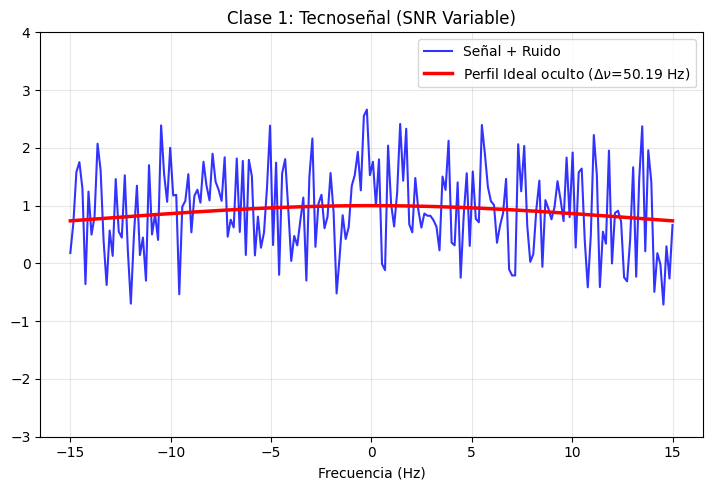

In [ ]:
# Visualizamos.
plt.figure(figsize=(14, 5))

# Tomamos un sistema al azar.
idx_ver = 8000
ancho_ref = anchos_simulados[idx_ver]

Gráfica de la Clase 0 (Ruido).
plt.subplot(1, 2, 1)
plt.plot(eje_frecuencias, X_clase0[idx_ver], color='gray', alpha=0.8)
plt.title(f'Clase 0: Solo Ruido (Estática).')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia Normalizada')
plt.ylim(-3, 4)
plt.grid(True, alpha=0.3)

# Gráfica de la Clase 1 (Señal Ensanchada).
plt.subplot(1, 2, 2)
plt.plot(eje_frecuencias, X_clase1[idx_ver], color='blue', alpha=0.8, label='Señal + Ruido')

# Reconstruimos la Lorentziana ideal para graficarla encima.
gamma_ref = ancho_ref / 2.0
lorentz_ref = cauchy.pdf(eje_frecuencias, loc=0, scale=gamma_ref)
lorentz_ref = lorentz_ref / np.max(lorentz_ref)

plt.plot(eje_frecuencias, lorentz_ref, color='red', linewidth=2.5,
         label=f'Perfil Ideal oculto ($\Delta\\nu$={ancho_ref:.2f} Hz)')

plt.title(f'Clase 1: Tecnoseñal (SNR Variable)')
plt.xlabel('Frecuencia (Hz)')
plt.ylim(-3, 4)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Parte de la red neuronal.

In [ ]:
# Cargamos los datos.
ruta_guardado = '/content/drive/MyDrive/Simulación de sistemas físicos/'
X_clase1 = np.load(ruta_guardado + 'X_clase1.npy')
y_clase1 = np.load(ruta_guardado + 'y_clase1.npy')
X_clase0 = np.load(ruta_guardado + 'X_clase0.npy')
y_clase0 = np.load(ruta_guardado + 'y_clase0.npy')

X_clase1.shape, y_clase1.shape, X_clase0.shape, y_clase0.shape

# Unimos las clases.
X = np.concatenate((X_clase1, X_clase0), axis=0)
y = np.concatenate((y_clase1, y_clase0), axis=0)

In [ ]:
# Separamos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Adaptamos las dimensiones para la CNN.
X_train = X_train.reshape(-1, 200, 1)
X_test = X_test.reshape(-1, 200, 1)

In [ ]:
# Construcción de la red.
def crear_modelo():
    modelo = models.Sequential()

    # Primera capa convolucional: Busca características locales (pendientes de la señal, picos pequeños).
    modelo.add(layers.Conv1D(filters=16, kernel_size=5, activation='relu',
    kernel_regularizer=regularizers.l2(0.005), input_shape=(200, 1)))
    # Reducimos ruido.
    modelo.add(layers.MaxPooling1D(pool_size=2))

    # Segunda capa convolucional: Combina las características para reconocer la campana completa.
    modelo.add(layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    modelo.add(layers.MaxPooling1D(pool_size=2))

    # Aplanamos la sálida en un vector.
    modelo.add(layers.Flatten())

    # Añadimos el clasificador (capa densa).
    modelo.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    # A la hora de entrenar apagamos neuronas por cada época.
    modelo.add(layers.Dropout(0.5))
    # Capa que decide.
    modelo.add(layers.Dense(1, activation='sigmoid'))

    return modelo

model = crear_modelo()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilamos el modelo.
model.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 196, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 98, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 96, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        49,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,881 (198.75 KB)

 Trainable params: 50,881 (198.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento de la red.
freno_emergencia = EarlyStopping(monitor='val_loss',
                                 patience=3,
                                 restore_best_weights=True,
                                 verbose=1)

history = model.fit(X_train, y_train,
                       epochs=20,           # Vueltas completas al dataset.
                       batch_size=32,       # Analiza 32 espectros a la vez.
                       validation_split=0.2, # Usa 20% del train para validar en tiempo real.
                       callbacks=[freno_emergencia],
                       verbose=1)

Epoch 1/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9565 - loss: 0.2247 - val_accuracy: 0.9689 - val_loss: 0.1388
Epoch 2/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9665 - loss: 0.1485 - val_accuracy: 0.9717 - val_loss: 0.1198
Epoch 3/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9664 - loss: 0.1374 - val_accuracy: 0.9714 - val_loss: 0.1134
Epoch 4/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.9676 - loss: 0.1260 - val_accuracy: 0.9713 - val_loss: 0.1064
Epoch 5/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9677 - loss: 0.1199 - val_accuracy: 0.9706 - val_loss: 0.1066
Epoch 6/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9678 - loss: 0.1175 - val_accuracy: 0.9721 - val_loss: 0.1013
Epoch 7/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9677 - loss: 0.1135 - val_accuracy: 0.9718 - val_loss: 0.1007
Epoch 8/20
1984/1984 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9675 -

In [ ]:
# Evaluamos a la red.
loss, precision = model.evaluate(X_test, y_test)
print(f"\nPrecisión final en el set de prueba: {precision*100:.2f}%")

620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9723 - loss: 0.0945

Precisión final en el set de prueba: 97.23%


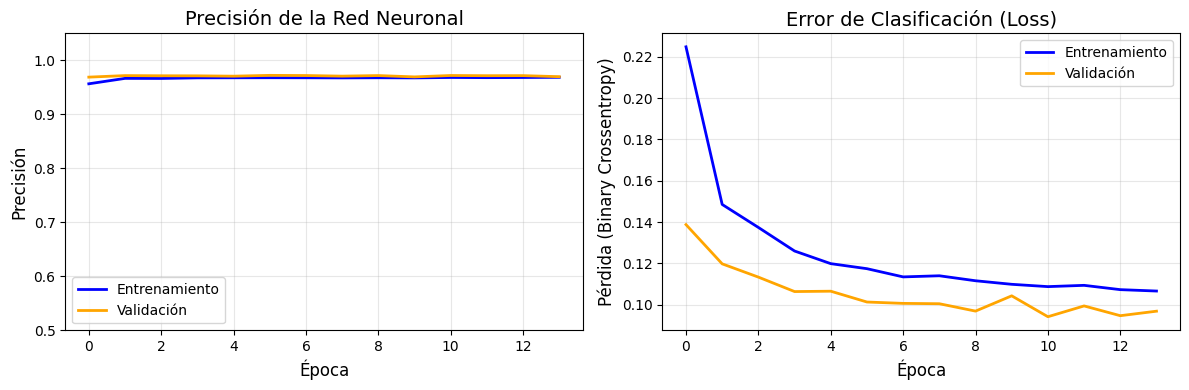

In [ ]:
# Gráfica de entrenamiento.
plt.figure(figsize=(12, 4))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
# Aseguramos usar el mismo nombre de la variable: history
plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación', color='orange', linewidth=2)
plt.title('Precisión de la Red Neuronal', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.ylim(0.5, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación', color='orange', linewidth=2)
plt.title('Error de Clasificación (Loss)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Guardamos el modelo.
ruta_modelo = '/content/drive/MyDrive/Simulación de sistemas físicos/red_clasificadora.keras'
model.save(ruta_modelo)

## Prueba de red con otros datos.

In [ ]:
# Cargamos el modelo.
modelo_cargado = tf.keras.models.load_model('/content/drive/MyDrive/Simulación de sistemas físicos/red_clasificadora.keras')
# Cargamos datos.
df_L = pd.read_csv('/content/drive/MyDrive/Simulación de sistemas físicos/L_50000_sistemas.csv')
anchos_L = df_L['Delta_nu_sb_Hz'].values

# Generamos las señales en base a los ensanchamientos.
X_L_clase1, y_L_clase1, X_L_clase0, y_L_clase0 = generar_dataset_separado(anchos_L, snr_min=0.5, snr_max=5.0)

# Unimos todo para hacer la prueba.
X_prueba_L = np.concatenate((X_L_clase1, X_L_clase0), axis=0)
y_verdadera = np.concatenate((y_L_clase1, y_L_clase0), axis=0)

# Adaptamos dimensiones para la CNN.
X_prueba_L = X_prueba_L.reshape(-1, 200, 1)

Generando dataset para 49565 sistemas con SNR variable entre 0.5 y 5.0...


In [ ]:
# Hacemos predicciones.
probabilidades = modelo_cargado.predict(X_prueba_L)
y_prediccion = (probabilidades > 0.5).astype(int).flatten()

# Generamos la matriz matemática.
matriz = confusion_matrix(y_verdadera, y_prediccion)

3098/3098 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


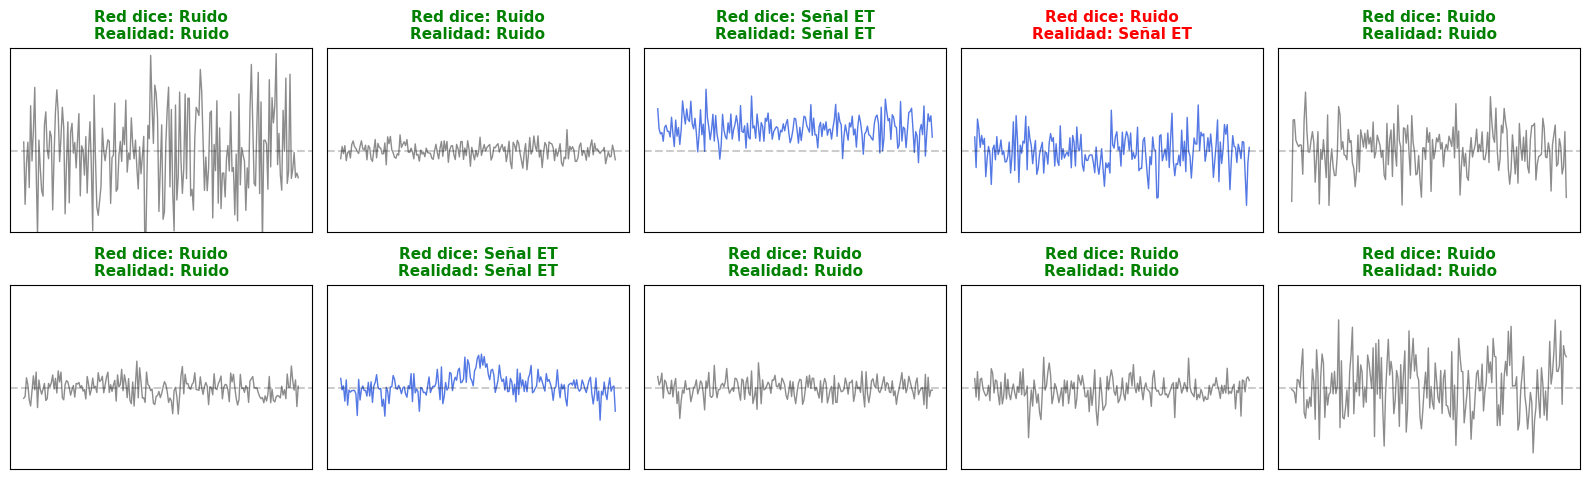

In [ ]:
# Graficamos diversas muestras.
num_muestras = 10
# Tomamos 25 índices al azar.
indices_aleatorios = np.random.choice(len(X_prueba_L), num_muestras, replace=False)

muestras_X = X_prueba_L[indices_aleatorios]
etiquetas_verdaderas = y_verdadera[indices_aleatorios]

# Que la red prediga las señales muestreadas.
probabilidades = modelo_cargado.predict(muestras_X)
etiquetas_predichas = (probabilidades > 0.5).astype(int).flatten()

nombres_clases = {0: "Ruido", 1: "Señal ET"}

# Visualizamos
plt.figure(figsize=(16, 12))

for i in range(num_muestras):
    # Creamos un subplot en una cuadrícula de 5 filas por 5 columnas.
    plt.subplot(5, 5, i+1)
    # Extraemos señal para graficarla.
    senal_1d = muestras_X[i].flatten()

    color_linea = 'royalblue' if etiquetas_verdaderas[i] == 1 else 'gray'
    plt.plot(eje_frecuencias, senal_1d, color=color_linea, alpha=0.9, linewidth=1)

    # Comprobamos si la red acertó.
    es_correcto = etiquetas_predichas[i] == etiquetas_verdaderas[i]
    color_titulo = 'green' if es_correcto else 'red'

    # Título de la gráfica individual.
    texto_pred = nombres_clases[etiquetas_predichas[i]]
    texto_real = nombres_clases[etiquetas_verdaderas[i]]
    plt.title(f"Red dice: {texto_pred}\nRealidad: {texto_real}",
              color=color_titulo, fontsize=11, fontweight='bold')

    plt.ylim(-3.5, 4.5)
    plt.xticks([])
    plt.yticks([])

    # Dibujamos una pequeña línea roja en el eje Y=0 como referencia visual del ruido.
    plt.axhline(0, color='black', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

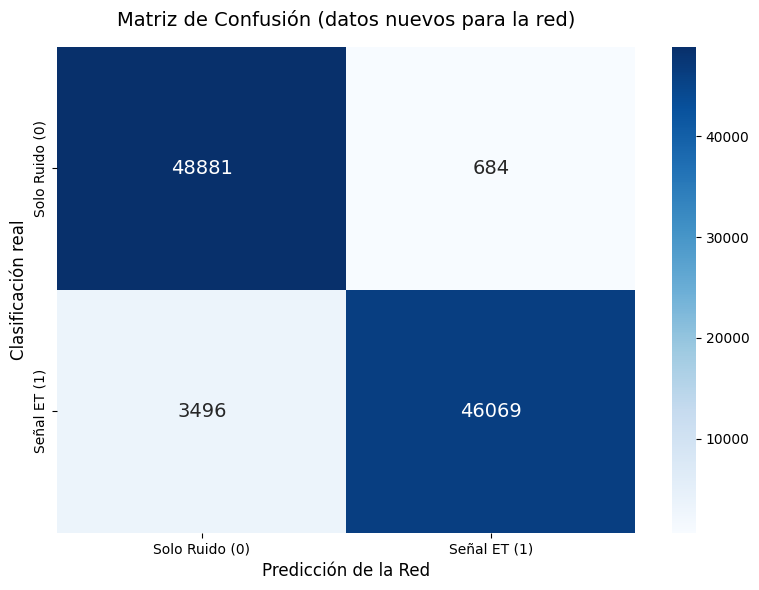

In [ ]:
# Visualizamos resultados.
plt.figure(figsize=(8, 6))
# Hacemos un mapa de calor.
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Solo Ruido (0)', 'Señal ET (1)'],
            yticklabels=['Solo Ruido (0)', 'Señal ET (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión (datos nuevos para la red)', fontsize=14, pad=15)
plt.ylabel('Clasificación real', fontsize=12)
plt.xlabel('Predicción de la Red', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- REPORTE DETALLADO DE CLASIFICACIÓN ---")
print(classification_report(y_verdadera, y_prediccion, target_names=['Solo Ruido', 'Señal ET']))


--- REPORTE DETALLADO DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

  Solo Ruido       0.94      0.99      0.96     49565
    Señal ET       0.99      0.93      0.96     49565

    accuracy                           0.96     99130
   macro avg       0.96      0.96      0.96     99130
weighted avg       0.96      0.96      0.96     99130

